In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
print("imported successfully")

imported successfully


In [34]:
df = pd.read_csv("cars.csv")
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


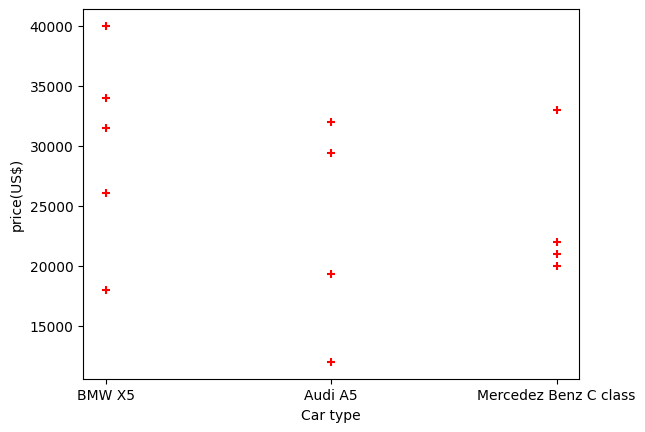

In [35]:
plt.xlabel('Car type')
plt.ylabel('price(US$)')
plt.scatter(df["Car Model"], df["Sell Price($)"], color='red', marker='+')

In [8]:
dummy = pd.get_dummies(df["Car Model"])

In [14]:
merged = pd.concat([dummy, df], axis='columns')
merged

,Audi A5,BMW X5,Mercedez Benz C class,Car Model,Mileage,Sell Price($),Age(yrs)
0,False,True,False,BMW X5,69000,18000,6
1,False,True,False,BMW X5,35000,34000,3
2,False,True,False,BMW X5,57000,26100,5
3,False,True,False,BMW X5,22500,40000,2
4,False,True,False,BMW X5,46000,31500,4
5,True,False,False,Audi A5,59000,29400,5
6,True,False,False,Audi A5,52000,32000,5
7,True,False,False,Audi A5,72000,19300,6
8,True,False,False,Audi A5,91000,12000,8
9,False,False,True,Mercedez Benz C class,67000,22000,6


In [25]:
final =merged.drop(["Car Model", "Mercedez Benz C class"], axis='columns')
final

,Audi A5,BMW X5,Mileage,Sell Price($),Age(yrs)
0,False,True,69000,18000,6
1,False,True,35000,34000,3
2,False,True,57000,26100,5
3,False,True,22500,40000,2
4,False,True,46000,31500,4
5,True,False,59000,29400,5
6,True,False,52000,32000,5
7,True,False,72000,19300,6
8,True,False,91000,12000,8
9,False,False,67000,22000,6


In [26]:
X = final.drop(["Sell Price($)"], axis="columns")
X

,Audi A5,BMW X5,Mileage,Age(yrs)
0,False,True,69000,6
1,False,True,35000,3
2,False,True,57000,5
3,False,True,22500,2
4,False,True,46000,4
5,True,False,59000,5
6,True,False,52000,5
7,True,False,72000,6
8,True,False,91000,8
9,False,False,67000,6


In [28]:
reg = LinearRegression()

In [29]:
reg.fit(X, merged["Sell Price($)"])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
reg.predict(pd.DataFrame([[0, 0, 45000, 4]], columns=["Audi A5","BMW X5","Mileage","Age(yrs)"]))

array([36991.31721061])

In [36]:
reg.predict(pd.DataFrame([[0, 1, 86000, 7]], columns=["Audi A5","BMW X5","Mileage","Age(yrs)"]))

array([11080.74313219])

In [37]:
reg.score(X,merged["Sell Price($)"])

0.9417050937281082

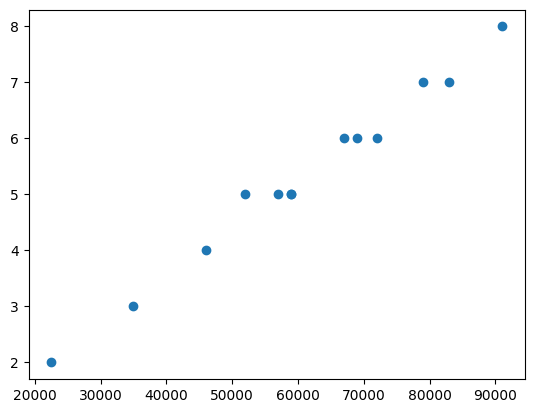

In [20]:
plt.scatter(merged.Mileage, merged["Age(yrs)"])